# Imports & File Path Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import emcee
import corner
import os

# Create plots directory if it doesn't exist
os.makedirs("plots", exist_ok=True)

# Define exact file paths to your saved HDF5 chains
# (Adjust these names slightly if your SNe file was saved as cpl_sne_shoes_prior.h5)
paths = {
    "SNe": "mcmc_chains/SNe.h5",
    "CC":  "mcmc_chains/cpl_cc.h5",
    "BAO": "mcmc_chains/cpl_bao.h5"
}

# Verify all files exist before proceeding
for name, path in paths.items():
    if os.path.exists(path):
        print(f"✅ Found {name} chain: {path}")
    else:
        print(f"❌ Missing {name} chain: {path} (Please check filename!)")

✅ Found SNe chain: mcmc_chains/SNe.h5
✅ Found CC chain: mcmc_chains/cpl_cc.h5
✅ Found BAO chain: mcmc_chains/cpl_bao.h5


# Extract & Align the Common Parameter Samples

In [2]:
# ---------------------------------------------------------
# Extract & Align Common Parameters: (Omega_m, H_0, w0, wa)
# ---------------------------------------------------------
samples_common = {}

# 1. Extract SNe: Original indices [0: Omega_m, 1: H_0, 2: M_B, 3: w0, 4: wa]
# We want columns [0, 1, 3, 4] (skipping M_B)
reader_sn = emcee.backends.HDFBackend(paths["SNe"])
chain_sn = reader_sn.get_chain(discard=int(reader_sn.iteration * 0.5), thin=15, flat=True)
samples_common["SNe (with SH0ES)"] = chain_sn[:, [0, 1, 2, 3]]

# 2. Extract CC: Original indices [0: Omega_m, 1: H_0, 2: w0, 3: wa]
# We want all columns [0, 1, 2, 3]
reader_cc = emcee.backends.HDFBackend(paths["CC"])
chain_cc = reader_cc.get_chain(discard=int(reader_cc.iteration * 0.5), thin=15, flat=True)
samples_common["CC Only"] = chain_cc[:, [0, 1, 2, 3]]

# 3. Extract BAO: Original indices [0: Omega_m, 1: H_0, 2: r_d, 3: w0, 4: wa]
# We want columns [0, 1, 3, 4] (skipping r_d)
reader_bao = emcee.backends.HDFBackend(paths["BAO"])
chain_bao = reader_bao.get_chain(discard=int(reader_bao.iteration * 0.5), thin=15, flat=True)
samples_common["BAO Only"] = chain_bao[:, [0, 1, 3, 4]]

print("Successfully extracted and aligned common parameter samples for all 3 datasets!")
for name, data in samples_common.items():
    print(f"  -> {name}: {data.shape[0]} samples across 4 parameters")

Successfully extracted and aligned common parameter samples for all 3 datasets!
  -> SNe (with SH0ES): 23000 samples across 4 parameters
  -> CC Only: 12000 samples across 4 parameters
  -> BAO Only: 41650 samples across 4 parameters


# Generate the Overlaid 3-Way Corner Plot

Successfully extracted aligned parameter samples!
✅ Overlaid comparison plot saved successfully to: plots/SNe_CC_BAO_overlap_check.png


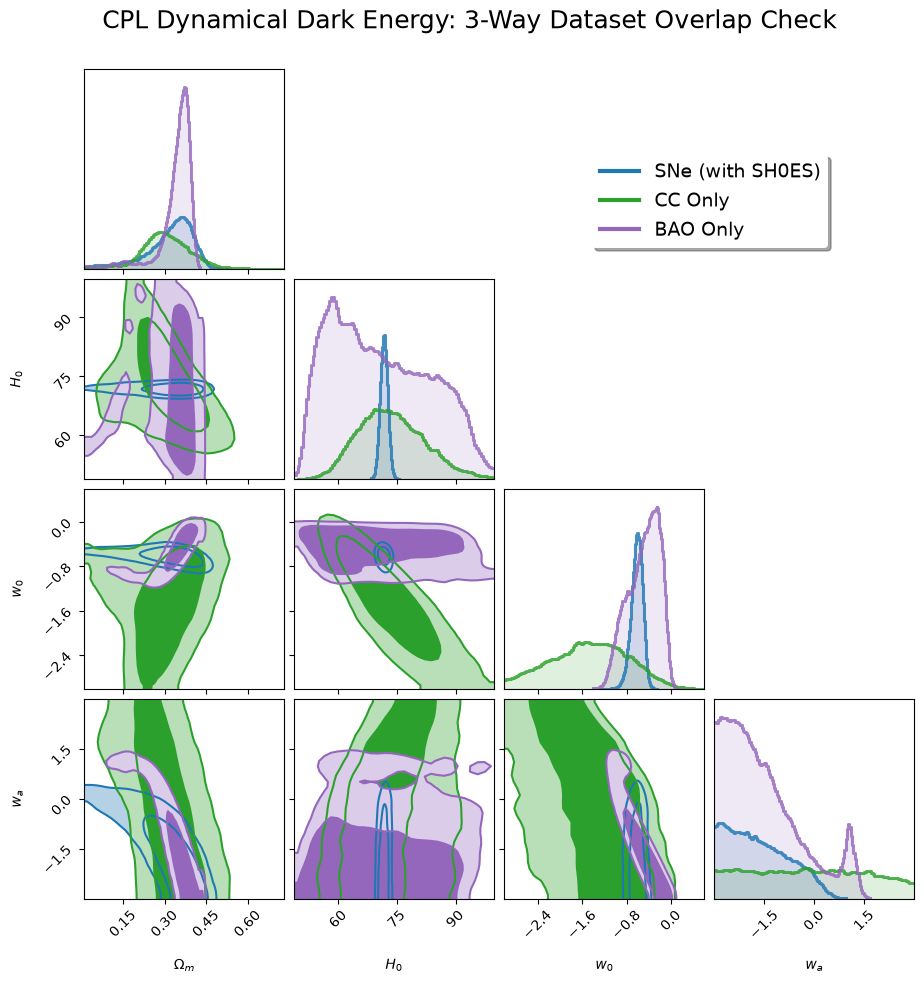

In [3]:
# ---------------------------------------------------------
# Extract & Align Common Parameters: (Omega_m, H_0, w0, wa)
# ---------------------------------------------------------
paths = {
    "SNe": "mcmc_chains/cpl_sne_shoes_prior.h5",
    "CC":  "mcmc_chains/cpl_cc.h5",
    "BAO": "mcmc_chains/cpl_bao.h5"
}

samples_common = {}

# 1. Extract SNe: columns [0, 1, 3, 4] (skipping M_B)
reader_sn = emcee.backends.HDFBackend(paths["SNe"])
chain_sn = reader_sn.get_chain(discard=int(reader_sn.iteration * 0.5), thin=15, flat=True)
samples_common["SNe (with SH0ES)"] = chain_sn[:, [0, 1, 3, 4]]

# 2. Extract CC: columns [0, 1, 2, 3]
reader_cc = emcee.backends.HDFBackend(paths["CC"])
chain_cc = reader_cc.get_chain(discard=int(reader_cc.iteration * 0.5), thin=15, flat=True)
samples_common["CC Only"] = chain_cc[:, [0, 1, 2, 3]]

# 3. Extract BAO: columns [0, 1, 3, 4] (skipping r_d)
reader_bao = emcee.backends.HDFBackend(paths["BAO"])
chain_bao = reader_bao.get_chain(discard=int(reader_bao.iteration * 0.5), thin=15, flat=True)
samples_common["BAO Only"] = chain_bao[:, [0, 1, 3, 4]]

print("Successfully extracted aligned parameter samples!")

# ---------------------------------------------------------
# Plot Overlaid Contours to Check Parameter Intersection
# ---------------------------------------------------------
labels = [r"$\Omega_m$", r"$H_0$", r"$w_0$", r"$w_a$"]

colors = {
    "SNe (with SH0ES)": "#1f77b4",  # Blue
    "CC Only":          "#2ca02c",  # Green
    "BAO Only":         "#9467bd"   # Purple
}

fig = None

for name, samples in samples_common.items():
    fig = corner.corner(
        samples,
        fig=fig,                 
        labels=labels,
        levels=[0.68, 0.95],     
        color=colors[name],
        fill_contours=True,      
        plot_datapoints=False,   
        plot_density=False,
        smooth=1.2,              
        smooth1d=1.5,            
        bins=30,
        hist_bin_factor=4,       
        show_titles=False,       
        hist_kwargs={
            "linewidth": 2.2,
            "alpha": 0.8         
        }
        # Note: contourf_kwargs is intentionally omitted to prevent matplotlib array shape clashes!
    )

# Manually apply shaded fill beneath the overlaid 1D curves
ndim = len(labels)
for i in range(ndim):
    ax = fig.axes[i * ndim + i]
    for line in ax.get_lines():
        x_data, y_data = line.get_data()
        line_color = line.get_color()
        ax.fill_between(x_data, 0, y_data, color=line_color, alpha=0.15)

# Add Legend
legend_handles = [
    mlines.Line2D([], [], color=colors[name], linewidth=3, label=name)
    for name in samples_common.keys()
]
fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.88, 0.88),
    fontsize=14,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    shadow=True
)

plt.suptitle("CPL Dynamical Dark Energy: 3-Way Dataset Overlap Check", y=1.02, fontsize=18)

save_path = "plots/SNe_CC_BAO_overlap_check.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"✅ Overlaid comparison plot saved successfully to: {save_path}")
plt.show()